# CatBoost-utfordrer for ren egen-skadepremie

Notebooken utvikler én CatBoost-modell med Tweedie-loss for forventet ren
egen-skadepremie per eksponeringsår. Den utfordrer Tweedie-GLM-en på samme
populasjon, med samme Tweedie-power, seed og gruppefolder. Bare
utviklingsårene 2022–2023 er brukt; 2024 er ikke lest.

In [1]:
from IPython.display import display

from src_core_glm.model_data import build_development_frames
from src_ml.catboost_pricing import (
    build_catboost_result_table,
    fit_catboost_grid,
    plot_catboost_diagnostics,
    prepare_catboost_features,
)
from src_model_comparison.locked_models import lock_catboost
from src_model_comparison.variable_coverage import build_variable_coverage
from src_tweedie.tweedie_data import build_tweedie_frame

SEED = 100
N_SPLITS = 5
# Låst fra severity-implisert Tweedie-power i Tweedie-GLM-løpet.
TWEEDIE_POWER = 1.744

PREDICTORS = [
    "policy_type",
    "year",
    "driver_age",
    "log_vehicle_value",
    "performance_hp_per_tonne",
    "fuel_type",
    "circulation_area",
    "municipality_type",
    "payment_frequency",
    "business_type",
    "vehicle_brand_pooled",
    "seats",
]

CATEGORICAL_FEATURES = [
    "policy_type",
    "year",
    "fuel_type",
    "circulation_area",
    "municipality_type",
    "payment_frequency",
    "business_type",
    "vehicle_brand_pooled",
]

PARAM_GRID = {
    "depth": [4, 6],
    "learning_rate": [0.03, 0.07],
    "iterations": [300, 600],
    "l2_leaf_reg": [3.0, 10.0],
}

## 1. Datagrunnlag

Modellrammen bygges fra utviklingsårene 2022–2023. Kategoriske prediktorer
gis direkte til CatBoost; manglende verdier får egen kategori.

In [2]:
development = build_development_frames()["development"]
model_frame = build_tweedie_frame(development, PREDICTORS)
features = prepare_catboost_features(
    model_frame, PREDICTORS, CATEGORICAL_FEATURES
)
response = model_frame["pure_premium"]
sample_weight = model_frame["total_exposure"]
groups = model_frame["insured_id"]

## 2. Modell og seleksjonsregel

For poliseår $i$ er observert ren premie

$$
R_i = \frac{S_i}{e_i},
$$

der $S_i$ er incurred egen-skadekostnad og $e_i$ er eksponering. CatBoost
estimerer forventet ren premie $\widehat\mu_i = f_\theta(x_i)$ ved å minimere
eksponeringsvektet Tweedie-deviance med låst $p$. Hyperparameterne velges av
et lite rutenett (16 kombinasjoner) ved å minimere

$$
D_p = \operatorname{mean\_tweedie\_deviance}
\left(R, \widehat\mu;\, w=e,\, p\right)
$$

over fem gruppefolder på `insured_id`. Gruppefoldene hindrer at samme
forsikringstaker står på begge sider av en fold. Etter valget refittes
modellen på alle utviklingsdata.

In [3]:
result = fit_catboost_grid(
    features,
    response,
    sample_weight,
    groups,
    CATEGORICAL_FEATURES,
    TWEEDIE_POWER,
    PARAM_GRID,
    n_splits=N_SPLITS,
    seed=SEED,
)

## 3. Resultat og diagnostikk

Rutenettet valgte `depth` 4, `learning_rate` 0.03, `iterations` 300 og
`l2_leaf_reg` 3.0. `grid_mean_deviance` er scoren som valgte disse.
`pooled_oof_deviance` er beregnet fra de samme foldenes OOF-prediksjoner og
er derfor optimistisk. Nullmodellen er treningsfoldens eksponeringsvektede
gjennomsnitt.

In [4]:
result_table = build_catboost_result_table(result)
display(result_table.round(4))

,depth,iterations,l2_leaf_reg,learning_rate,grid_mean_deviance,grid_deviance_std,pooled_oof_deviance,null_oof_deviance,oof_d2
0,4,300,3.0,0.03,33.2782,0.3589,33.2775,34.0919,0.0239


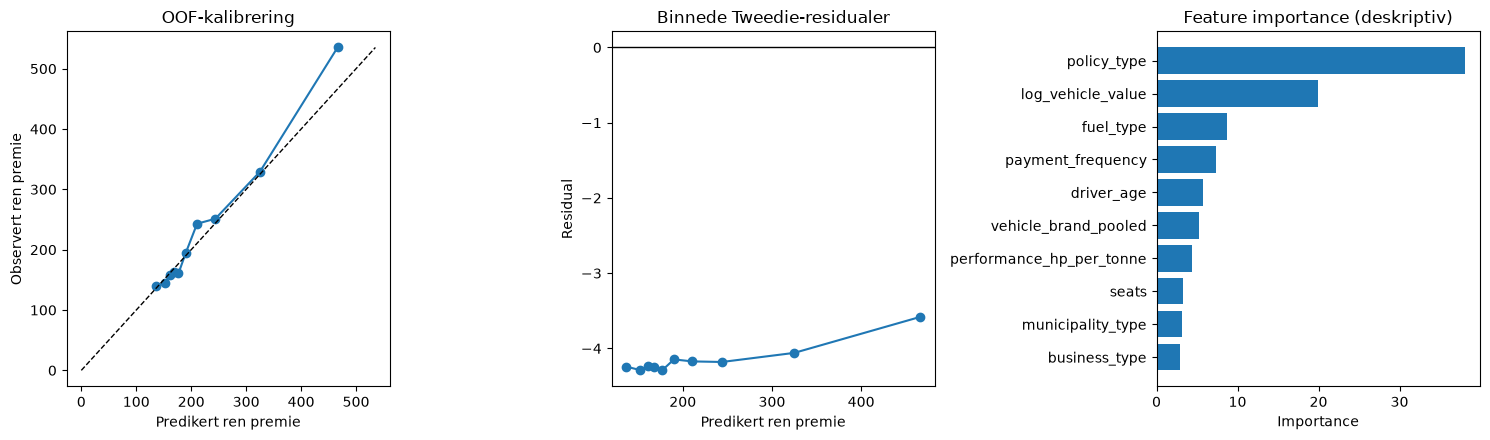

In [5]:
figure = plot_catboost_diagnostics(result)

## 4. Endelig modell

Den endelige modellen er CatBoost med log-link, refittet på alle
utviklingsdata:

$$
\widehat\mu(x) = \exp\{F_M(x)\}, \qquad
F_M(x) = \sum_{m=1}^{M} \eta\, t_m(x),
$$

der $t_m$ er symmetriske (oblivious) beslutningstrær av dybde $d = 4$ (16
blader per tre), læringsraten er $\eta = 0.03$, antall trær er $M = 300$ og
bladverdiene har $L_2$-regularisering $\lambda = 3.0$. Trærne bygges
sekvensielt for å minimere $D_p$ fra §2 med eksponeringsvekt $w=e$ og låst
$p = 1.744$. Totalt gir det $300 \cdot 2^4 = 4800$ bladverdier.

In [6]:
# Sikrer at LaTeX-teksten over stemmer med den valgte modellen (kan fjernes).
assert result["search"].best_params_ == {
    "depth": 4,
    "iterations": 300,
    "l2_leaf_reg": 3.0,
    "learning_rate": 0.03,
}
assert result["best_estimator"].tree_count_ == 300
assert TWEEDIE_POWER == 1.744

## 5. Variabelsjekk og låst modell

Alle prediktorer er tilgjengelige for CatBoost; ingen er utelatt av
seleksjon. Kontrollen feiler hvis en kolonne i utviklingsdata verken er
brukt, bevisst utelatt eller utfall/ID. Den låste modellen lagres i
`models/catboost.joblib` og verifiseres mot notebookens egne prediksjoner.

In [7]:
coverage = build_variable_coverage(development, PREDICTORS, PREDICTORS, PREDICTORS)
display(coverage)

,variabel,status,begrunnelse
0,year,i endelig modell,
1,policy_type,i endelig modell,
2,policy_status,utelatt,ukjent om status er kjent ved periodestart
3,business_type,i endelig modell,
4,payment_frequency,i endelig modell,
5,bonus_score,utelatt,tidspunkt for fastsettelse uavklart (lekkasjer...
6,driver_age,i endelig modell,
7,vehicle_age,utelatt,uklar betydning i kildedokumentasjonen
8,age_driving_licence,utelatt,rå verdi; erstattet av utledet erfaring
9,fuel_type,i endelig modell,


In [8]:
display(
    lock_catboost(
        "catboost", result, PREDICTORS, CATEGORICAL_FEATURES, development
    )
)

,modell,fil,størrelse_MB,rader_kontrollert,snitt_prediksjon
0,catboost,models/catboost.joblib,0.14,36254,224.633808


## 6. Begrensninger

- **Optimistisk utviklingsscore.** Samme fem folder velger hyperparameterne
  og scorer dem; `pooled_oof_deviance` er derfor ikke et uavhengig estimat.
- **Lite rutenett.** Bare 16 kombinasjoner er testet, og alle valgte verdier
  ligger i den lave enden av rutenettet, så mer forsiktige oppsett er ikke
  utforsket. CatBoost har ikke tidlig stopp eller egen valideringsdel utover
  CV.
- **Lav forklart deviance.** $D^2 = 0.0239$ mot nullmodellen; skadekostnad er
  svært støyende. $p$ er låst fra Tweedie-GLM-løpet og ikke tunet her.
- **Feature importance er deskriptiv**, ikke kausal, og sier ikke noe om
  retning eller størrelse på effekten.
- **`year` er en låst kategorisk term**, og 2024 finnes ikke i treningsdata.
  2024 skåres derfor med 2023-nivået: ingen trend-ekstrapolering, og
  årsdrift blir liggende i porteføljebalansen.
- **Numeriske prediktorer klippes til treningsområdet** ved skåring; trærne
  er flate utenfor det.